<a href="https://colab.research.google.com/github/luizcodedthat/sistema-monitoramento-camara-fria/blob/main/ml/IsolationForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================
# CÉLULA 1 — INSTALAÇÃO
# =========================
%pip install -q joblib scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# =========================
# CÉLULA 2 — IMPORTS
# =========================
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
)

In [ ]:
# =========================
# CÉLULA 3 — CONFIGURAÇÃO
# =========================
FEATURES = [
    "temp_interna",
    "umidade_interna",
    "porta_aberta_min",
    "temp_externa",
    "umidade_externa",
    "hora_leitura",
]

In [ ]:
# =========================
# CÉLULA 4 — GERAÇÃO DO DATASET SINTÉTICO (VERSÃO MELHORADA)
# =========================

def generate_dataset(n_rows=20000, start="2026-01-01", freq="15min", seed=42):
    import numpy as np
    import pandas as pd

    rng = np.random.default_rng(seed)
    idx = pd.date_range(start=start, periods=n_rows, freq=freq)

    hour = (idx.hour + idx.minute / 60.0).to_numpy()
    dayofweek = idx.dayofweek.to_numpy()

    # =========================
    # VARIÁVEIS EXTERNAS
    # =========================

    temp_externa = (
        28
        + 4 * np.sin(2 * np.pi * hour / 24)
        + 1.2 * np.sin(2 * np.pi * dayofweek / 7)
        + rng.normal(0, 0.6, n_rows)   # ruído menor
    )

    umidade_externa = (
        70
        - 8 * np.sin(2 * np.pi * hour / 24)
        + 2 * np.cos(2 * np.pi * dayofweek / 7)
        + rng.normal(0, 1.5, n_rows)   # ruído menor
    )

    porta_base = rng.gamma(shape=1.4, scale=1.8, size=n_rows)

    porta_aberta_min = np.clip(
        porta_base
        + np.where(
            (hour >= 8) & (hour <= 18),
            rng.normal(0.7, 0.8, n_rows),
            rng.normal(-0.4, 0.4, n_rows),
        ),
        0,
        None,
    )

    # =========================
    # VARIÁVEIS INTERNAS
    # =========================

    temp_interna = (
        22.0
        + 0.1 * (temp_externa - 26)
        + 0.05 * porta_aberta_min
        + rng.normal(0, 0.1, n_rows)  # menos ruído
    )

    umidade_interna = (
        82
        + 0.12 * (umidade_externa - 70)
        + 0.18 * porta_aberta_min
        - 0.2 * (temp_interna - 22.0)
        + rng.normal(0, 1.0, n_rows)
    )

    # =========================
    # FEATURE NOVA (IMPORTANTE)
    # =========================

    compressor_health = np.ones(n_rows)

    # =========================
    # ANOMALIAS
    # =========================

    anomaly_mask = np.zeros(n_rows, dtype=bool)

    # -------------------------------------------------
    # 1. ANOMALIAS SEVERAS
    # -------------------------------------------------

    n_criticas = max(1, int(0.01 * n_rows))

    critical_idx = rng.choice(n_rows, size=n_criticas, replace=False)

    for i in critical_idx:

        kind = rng.integers(0, 3)

        if kind == 0:
            porta_aberta_min[i] += rng.uniform(10, 20)
            temp_interna[i] += rng.uniform(2.5, 5.0)

        elif kind == 1:
            temp_interna[i] += rng.uniform(3.0, 7.0)
            umidade_interna[i] += rng.uniform(10, 25)

        else:
            umidade_interna[i] += rng.uniform(25, 40)

        anomaly_mask[i] = True

    # -------------------------------------------------
    # 2. DETECÇÃO PRECOCE (EFEITO UAU)
    # -------------------------------------------------

    n_precoce = max(20, int(0.004 * n_rows))

    precoce_starts = rng.choice(
        np.arange(100, n_rows - 50),
        size=n_precoce,
        replace=False
    )

    for start_idx in precoce_starts:

        duracao = rng.integers(16, 40)  # 4 a 10 horas

        tipo = rng.integers(0, 2)

        for k in range(duracao):

            i = start_idx + k
            if i >= n_rows:
                break

            fator = (k + 1) / duracao

            if tipo == 0:
                # Porta ficando progressivamente problemática
                porta_aberta_min[i] += fator * rng.uniform(2, 6)

                temp_interna[i] += fator * rng.uniform(0.8, 2.5)

            else:
                # Compressor degradando (principal)
                temp_interna[i] += fator * rng.uniform(1.2, 3.5)

                umidade_interna[i] += fator * rng.uniform(2, 6)

                compressor_health[i] -= fator * rng.uniform(0.03, 0.12)

            anomaly_mask[i] = True

    # =========================
    # DATAFRAME FINAL
    # =========================

    df = pd.DataFrame({
        "timestamp": idx,
        "temp_interna": temp_interna,
        "umidade_interna": umidade_interna,
        "porta_aberta_min": porta_aberta_min,
        "temp_externa": temp_externa,
        "umidade_externa": umidade_externa,
        "hora_leitura": hour,
        "compressor_health": compressor_health,
        "is_anomaly_synthetic": anomaly_mask.astype(int),
    })

    return df

In [ ]:
# =========================
# CÉLULA 5 — SPLIT TEMPORAL 70/30
# =========================
def temporal_train_test_split(df, test_size=0.30):
    df = df.sort_values("timestamp").reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_size))
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    return train_df, test_df

In [ ]:
# =========================
# CÉLULA 6 — PIPELINE E TREINO
# =========================
def build_pipeline(contamination=0.03, random_state=42):
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                IsolationForest(
                    n_estimators=300,
                    contamination=contamination,
                    random_state=random_state,
                    n_jobs=-1,
                ),
            ),
        ]
    )

def train_model(train_df, contamination=0.03, random_state=42):
    X_train = train_df[FEATURES].copy()
    pipe = build_pipeline(contamination=contamination, random_state=random_state)
    pipe.fit(X_train)
    return pipe

In [ ]:
# =========================
# CÉLULA 7 — AVALIAÇÃO
# =========================
def evaluate_model(model, test_df):
    X_test = test_df[FEATURES].copy()
    y_true = test_df["is_anomaly_synthetic"].astype(int).to_numpy()

    # IsolationForest: -1 = anomalia, 1 = normal
    y_pred_raw = model.predict(X_test)
    y_pred = (y_pred_raw == -1).astype(int)

    # Quanto menor a decision_function, mais anômalo
    anomaly_score = -model.decision_function(X_test)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, anomaly_score)
    except ValueError:
        metrics["roc_auc"] = np.nan

    print("Relatório de classificação:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["normal", "anomalia"],
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm, y_pred, anomaly_score

In [ ]:
# =========================
# CÉLULA 8 — PLOT DA MATRIZ DE CONFUSÃO
# =========================
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()

In [ ]:
# =========================
# CÉLULA 9 — SALVAR ARTEFATOS
# =========================
def save_artifacts(model, output_dir="/content/output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    model_path = output_dir / "isolation_forest_model.joblib"
    meta_path = output_dir / "model_metadata.json"

    joblib.dump(model, model_path)

    metadata = {
        "features": FEATURES,
        "model_type": "Pipeline(StandardScaler + IsolationForest)",
        "version": "1.0",
    }

    meta_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

    return model_path, meta_path

Total: 20000
Treino: 14000
Teste: 6000
Anomalias no treino: 1730
Anomalias no teste: 508
Relatório de classificação:
              precision    recall  f1-score   support

      normal       0.94      0.99      0.97      5492
    anomalia       0.82      0.29      0.42       508

    accuracy                           0.93      6000
   macro avg       0.88      0.64      0.69      6000
weighted avg       0.93      0.93      0.92      6000


Métricas:
accuracy: 0.9343
precision: 0.8239
recall: 0.2854
f1: 0.4240
roc_auc: 0.8412

Modelo salvo em: /content/output/isolation_forest_model.joblib
Metadados salvos em: /content/output/model_metadata.json


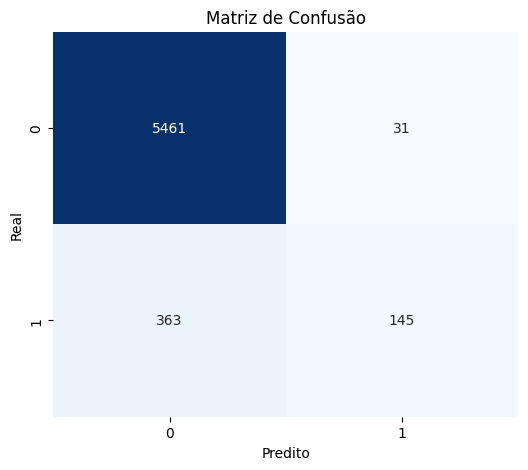

In [ ]:
# =========================
# CÉLULA 10 — EXECUÇÃO COMPLETA
# =========================
df = generate_dataset(n_rows=20000, seed=42)

train_df, test_df = temporal_train_test_split(df, test_size=0.30)

print(f"Total: {len(df)}")
print(f"Treino: {len(train_df)}")
print(f"Teste: {len(test_df)}")
print(f"Anomalias no treino: {train_df['is_anomaly_synthetic'].sum()}")
print(f"Anomalias no teste: {test_df['is_anomaly_synthetic'].sum()}")

model = train_model(train_df, contamination=0.03, random_state=42)

metrics, cm, y_pred, anomaly_score = evaluate_model(model, test_df)

model_path, meta_path = save_artifacts(model, output_dir="/content/output")

print("\nMétricas:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print(f"\nModelo salvo em: {model_path}")
print(f"Metadados salvos em: {meta_path}")

plot_confusion_matrix(cm)

In [ ]:
# =========================
# CÉLULA 11 — VISUALIZAÇÃO DAS PREDIÇÕES NO TESTE
# =========================
test_result = test_df.copy()
test_result["isolation_pred"] = y_pred
test_result["anomaly_score"] = anomaly_score

test_result.head()

,timestamp,temp_interna,umidade_interna,porta_aberta_min,temp_externa,umidade_externa,hora_leitura,compressor_health,is_anomaly_synthetic,isolation_pred,anomaly_score
14000,2026-05-26 20:00:00,22.253753,84.608470,0.447186,25.365105,79.192216,20.00,1.0,0,0,-0.102844
14001,2026-05-26 20:15:00,22.043226,82.561748,0.008671,26.254466,79.147581,20.25,1.0,0,0,-0.114630
14002,2026-05-26 20:30:00,22.248472,83.215543,0.796572,27.101860,78.758296,20.50,1.0,0,0,-0.114294
14003,2026-05-26 20:45:00,22.172136,83.223160,4.344500,26.038630,72.406596,20.75,1.0,0,0,-0.138472
14004,2026-05-26 21:00:00,22.189210,84.226668,2.375046,26.105827,76.800818,21.00,1.0,0,0,-0.142794


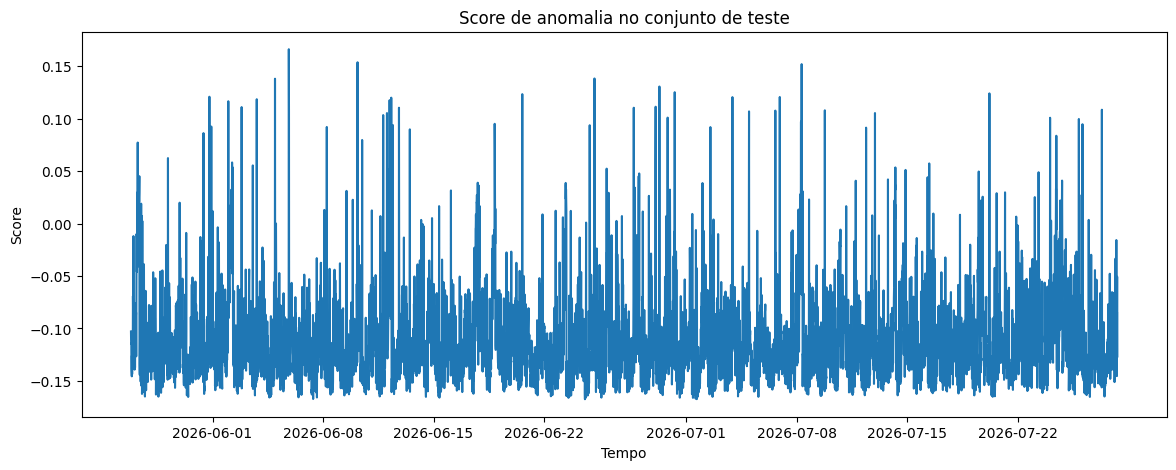

In [ ]:
# =========================
# CÉLULA 12 — SCORE AO LONGO DO TEMPO
# =========================
plt.figure(figsize=(14, 5))
plt.plot(test_result["timestamp"], test_result["anomaly_score"])
plt.title("Score de anomalia no conjunto de teste")
plt.xlabel("Tempo")
plt.ylabel("Score")
plt.show()


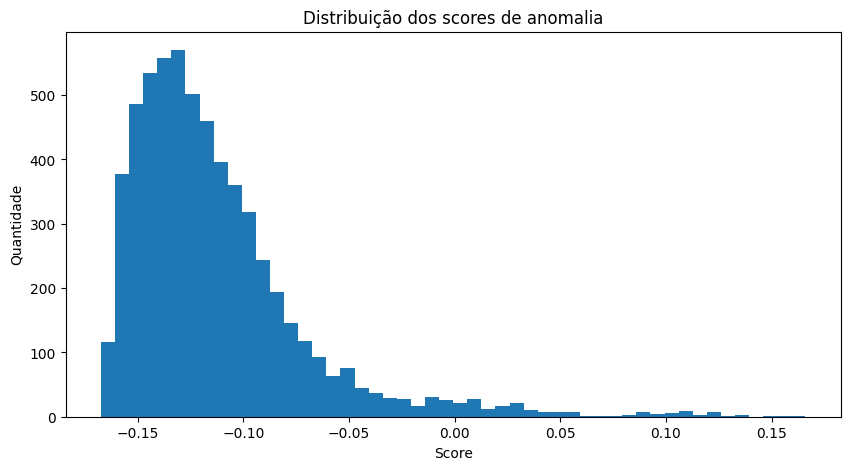

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    test_result["anomaly_score"],
    bins=50
)

plt.title("Distribuição dos scores de anomalia")
plt.xlabel("Score")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
test_result["isolation_pred"] = y_pred
test_result["anomaly_score"] = anomaly_score
test_result.sort_values(
    "anomaly_score",
    ascending=False
).head(20)

,timestamp,temp_interna,umidade_interna,porta_aberta_min,temp_externa,umidade_externa,hora_leitura,compressor_health,is_anomaly_synthetic,isolation_pred,anomaly_score
14960,2026-06-05 20:00:00,27.959896,103.692015,11.276160,23.279610,74.174726,20.00,1.000000,1,1,0.166053
15378,2026-06-10 04:30:00,28.169970,100.470663,0.000000,33.480370,60.354540,4.50,1.000000,1,1,0.153615
18079,2026-07-08 07:45:00,27.215265,105.911012,6.522689,33.179161,61.200281,7.75,1.000000,1,1,0.151838
16819,2026-06-25 04:45:00,29.146676,95.044884,0.000000,31.391138,58.774178,4.75,1.000000,1,1,0.138174
14876,2026-06-04 23:00:00,27.378676,105.263253,0.000000,27.030372,69.241293,23.00,1.000000,1,1,0.137941
17214,2026-06-29 07:30:00,28.195008,102.209344,0.222208,31.779320,64.690683,7.50,1.000000,1,1,0.130512
17307,2026-06-30 06:45:00,26.752770,101.335727,3.780958,33.136340,61.903610,6.75,1.000000,1,1,0.125101
19221,2026-07-20 05:15:00,27.219978,107.075987,3.609670,31.911797,62.840889,5.25,1.000000,1,1,0.123971
16380,2026-06-20 15:00:00,27.420623,104.631439,4.340973,24.441165,75.970344,15.00,1.000000,1,1,0.123245
14477,2026-05-31 19:15:00,24.792817,85.432364,17.603488,23.077321,79.406983,19.25,1.000000,1,1,0.120782


Total:               20000
Treino:              14000
Teste:               6000
Anomalias no treino: 1073 (7.7 %)
Anomalias no teste:  526 (8.8 %)
Treino: 12927 amostras normais de 14000 total (92.3 %)
Contaminação (taxa esperada em produção): 0.08
Relatório de classificação:
              precision    recall  f1-score   support

      normal       0.97      0.92      0.94      5474
    anomalia       0.44      0.68      0.54       526

    accuracy                           0.90      6000
   macro avg       0.71      0.80      0.74      6000
weighted avg       0.92      0.90      0.91      6000


Métricas:
  accuracy: 0.8968
  precision: 0.4427
  recall: 0.6825
  f1: 0.5370
  roc_auc: 0.8721

Modelo salvo em: /content/output/isolation_forest_model.joblib
Metadados salvos em: /content/output/model_metadata.json


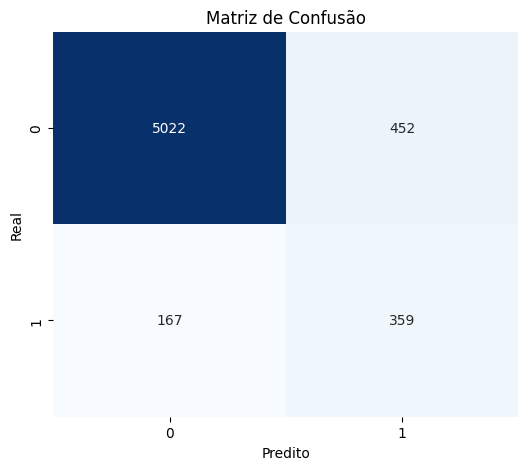

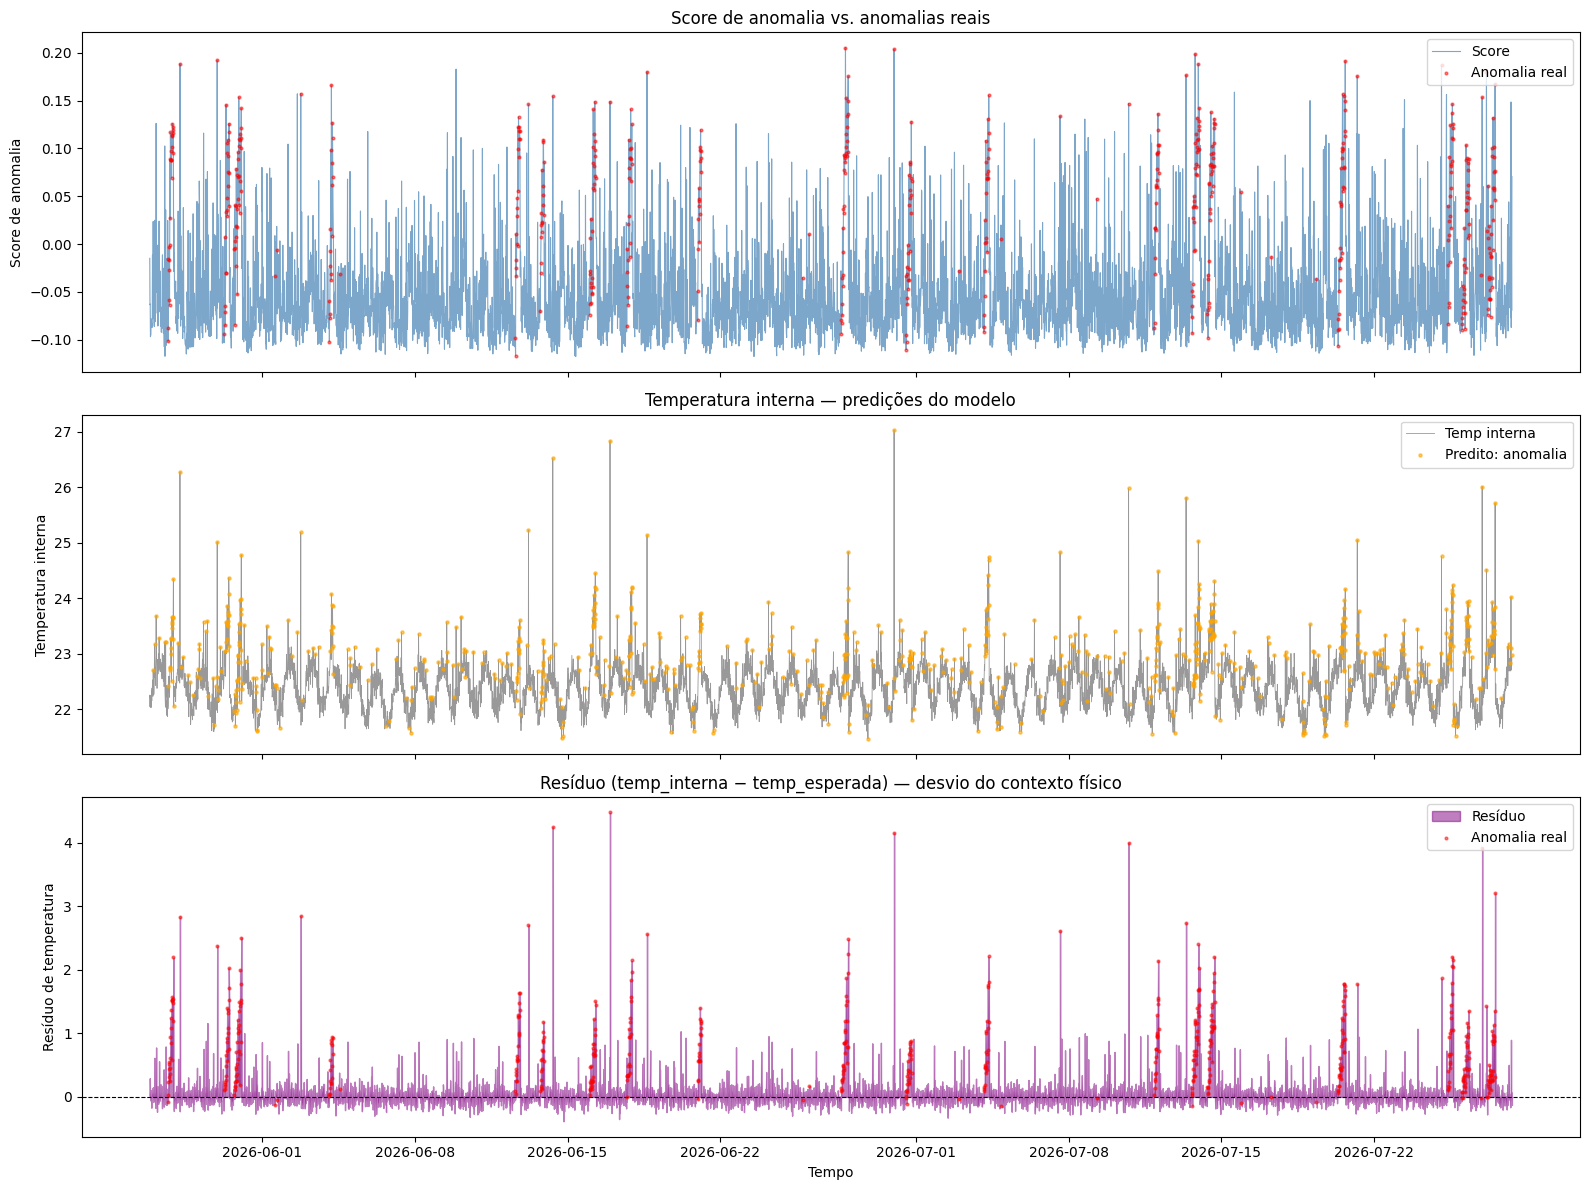

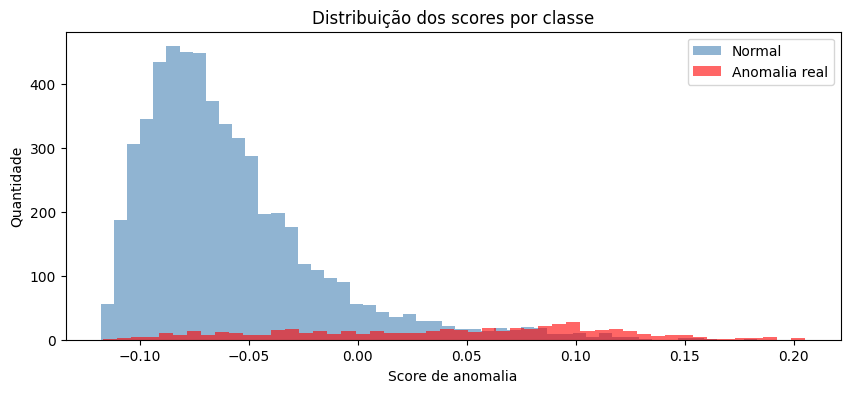

,timestamp,temp_interna,umidade_interna,porta_aberta_min,temp_externa,umidade_externa,hora_leitura,compressor_health,is_anomaly_synthetic,residual_temp,temp_delta,taxa_variacao_temp,interacao_porta_temp,isolation_pred,anomaly_score
17064,2026-06-27 18:00:00,23.351522,87.372450,14.126549,22.164861,76.290201,18.00,0.945107,1,1.028708,1.186661,0.199025,329.876423,1,0.205361
17278,2026-06-29 23:30:00,27.028697,94.041801,13.125402,28.146623,73.986980,23.50,1.000000,1,4.157764,-1.117927,1.166371,354.762502,1,0.203881
18604,2026-07-13 19:00:00,23.690524,87.989098,13.771360,24.583529,76.191768,19.00,0.984852,1,1.143603,-0.893005,0.316290,326.250747,1,0.199036
14297,2026-05-29 22:15:00,25.008515,81.984350,15.114300,24.714883,70.804230,22.25,1.000000,1,2.381311,0.293632,0.756663,377.986208,1,0.192256
19265,2026-07-20 16:15:00,24.164520,89.207929,12.003806,24.755437,79.488052,16.25,0.964390,1,1.688786,-0.590918,0.050403,290.066205,1,0.191714
14133,2026-05-28 05:15:00,26.276022,81.647831,14.030382,33.358873,61.113377,5.25,1.000000,1,2.838616,-7.082851,0.874832,368.662623,1,0.188625
18618,2026-07-13 22:30:00,25.033836,85.083366,12.630724,26.015018,73.906097,22.50,0.976765,1,2.400798,-0.981182,0.457093,316.195476,1,0.188539
19689,2026-07-25 02:15:00,24.755542,82.065816,12.699505,28.548415,63.280763,2.25,1.000000,1,1.865725,-3.792873,0.630338,314.383122,1,0.186944
15349,2026-06-09 21:15:00,23.480769,85.788027,11.543273,27.860231,80.688409,21.25,1.000000,0,0.717583,-4.379462,0.278750,271.044931,1,0.183014
19887,2026-07-27 03:45:00,24.516745,80.191627,12.052605,30.853019,64.293718,3.75,1.000000,1,1.428813,-6.336273,0.425506,295.490648,1,0.180504


In [ ]:
# -*- coding: utf-8 -*-
"""IsolationForest.ipynb — v3 (contextual + train-on-normal)"""

# =========================
# CÉLULA 1 — INSTALAÇÃO
# =========================
# %pip install -q joblib scikit-learn pandas numpy matplotlib seaborn

# =========================
# CÉLULA 2 — IMPORTS
# =========================
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
)

# =========================
# CÉLULA 3 — CONFIGURAÇÃO
# =========================
# 4 features contextuais adicionadas (ver CÉLULA 4.5)
FEATURES = [
    "temp_interna",
    "umidade_interna",
    "porta_aberta_min",
    "temp_externa",
    "umidade_externa",
    "hora_leitura",
    "residual_temp",         # desvio vs. temperatura esperada pelo modelo físico
    "temp_delta",            # diferença interno-externo
    "taxa_variacao_temp",    # velocidade de mudança da temp (rolling 1 h)
    "interacao_porta_temp",  # porta × temp interna (anula falso positivo de carga)
]

# Taxa de anomalia esperada em produção — define o threshold de decisão do IF
CONTAMINATION = 0.08

# =========================
# CÉLULA 4 — DATASET (taxa de anomalia corrigida para ~8 %)
# =========================
def generate_dataset(n_rows=20000, start="2026-01-01", freq="15min", seed=42):
    rng = np.random.default_rng(seed)
    idx = pd.date_range(start=start, periods=n_rows, freq=freq)

    hour      = (idx.hour + idx.minute / 60.0).to_numpy()
    dayofweek = idx.dayofweek.to_numpy()

    # ── Variáveis externas ──────────────────────────────────────────────────
    temp_externa = (
        28
        + 4   * np.sin(2 * np.pi * hour / 24)
        + 1.2 * np.sin(2 * np.pi * dayofweek / 7)
        + rng.normal(0, 0.6, n_rows)
    )
    umidade_externa = (
        70
        - 8 * np.sin(2 * np.pi * hour / 24)
        + 2 * np.cos(2 * np.pi * dayofweek / 7)
        + rng.normal(0, 1.5, n_rows)
    )
    porta_base = rng.gamma(shape=1.4, scale=1.8, size=n_rows)
    porta_aberta_min = np.clip(
        porta_base + np.where(
            (hour >= 8) & (hour <= 18),
            rng.normal(0.7, 0.8, n_rows),
            rng.normal(-0.4, 0.4, n_rows),
        ),
        0, None,
    )

    # ── Variáveis internas ──────────────────────────────────────────────────
    temp_interna = (
        22.0
        + 0.1  * (temp_externa - 26)
        + 0.05 * porta_aberta_min
        + rng.normal(0, 0.1, n_rows)
    )
    umidade_interna = (
        82
        + 0.12 * (umidade_externa - 70)
        + 0.18 * porta_aberta_min
        - 0.2  * (temp_interna - 22.0)
        + rng.normal(0, 1.0, n_rows)
    )

    compressor_health = np.ones(n_rows)
    anomaly_mask      = np.zeros(n_rows, dtype=bool)

    # ── 1. Anomalias críticas (0.5 %) ──────────────────────────────────────
    n_criticas = max(1, int(0.005 * n_rows))
    crit_idx   = rng.choice(n_rows, size=n_criticas, replace=False)
    for i in crit_idx:
        kind = rng.integers(0, 3)
        if kind == 0:
            porta_aberta_min[i] += rng.uniform(8, 15)
            temp_interna[i]     += rng.uniform(1.5, 3.5)
        elif kind == 1:
            temp_interna[i]     += rng.uniform(2.0, 5.0)
            umidade_interna[i]  += rng.uniform(8, 18)
        else:
            umidade_interna[i]  += rng.uniform(15, 30)
        anomaly_mask[i] = True

    # ── 2. Detecção precoce ─────────────────────────────────────────────────
    # PROBLEMA ANTERIOR: int(0.02 * n_rows) = 400 starts × ~26 passos ≈ 10 400 pontos
    # → gerava 38-40 % de anomalias, impedindo o IF de aprender o que é "normal"
    # CORREÇÃO: 0.003 × n_rows = 60 starts → ~1 500 pontos ≈ 8 % do dataset
    n_precoce      = int(0.003 * n_rows)
    precoce_starts = rng.choice(np.arange(100, n_rows - 50), size=n_precoce, replace=False)
    for start_idx in precoce_starts:
        duracao = rng.integers(16, 36)
        tipo    = rng.integers(0, 2)
        for k in range(duracao):
            i = start_idx + k
            if i >= n_rows:
                break
            fator = (k + 1) / duracao
            if tipo == 0:
                porta_aberta_min[i] += fator * rng.uniform(1.5, 5.0)
                temp_interna[i]     += fator * rng.uniform(0.5, 1.8)
            else:
                temp_interna[i]     += fator * rng.uniform(0.8, 2.5)
                umidade_interna[i]  += fator * rng.uniform(1.5, 5.0)
                compressor_health[i] -= fator * rng.uniform(0.02, 0.10)
            anomaly_mask[i] = True

    # ── 3. Zona cinza — warning (3 %, NÃO rotulado como anomalia) ──────────
    n_warning   = int(0.03 * n_rows)
    warning_idx = rng.choice(np.where(~anomaly_mask)[0], size=n_warning, replace=False)
    for i in warning_idx:
        temp_interna[i]    += rng.uniform(0.3, 1.0)
        porta_aberta_min[i]+= rng.uniform(0.3, 1.5)
        umidade_interna[i] += rng.uniform(0.5, 2.0)

    return pd.DataFrame({
        "timestamp":            idx,
        "temp_interna":         temp_interna,
        "umidade_interna":      umidade_interna,
        "porta_aberta_min":     porta_aberta_min,
        "temp_externa":         temp_externa,
        "umidade_externa":      umidade_externa,
        "hora_leitura":         hour,
        "compressor_health":    compressor_health,
        "is_anomaly_synthetic": anomaly_mask.astype(int),
    })

# =========================
# CÉLULA 4.5 — FEATURE ENGINEERING (CONTEXTO FÍSICO DA CÂMARA)
# =========================
def add_contextual_features(df):
    """
    Transforma variáveis brutas em desvios do comportamento fisicamente esperado.
    Isso é o que permite ao Isolation Forest distinguir contexto, não apenas valor.

    CASO 1 — Compressor degradando silenciosamente:
        Com porta fechada e clima ameno, temp_interna deveria estar baixa.
        residual_temp alto nessa condição = anomalia clara para o modelo.

    CASO 2 — Falha de isolamento térmico (borrachas da porta):
        Após o fechamento da porta, temperatura não deveria subir.
        taxa_variacao_temp captura essa subida indevida.

    CASO 3 — Falso positivo (descarga de carga volumosa):
        Porta aberta + temp alta → interacao_porta_temp alto.
        O modelo aprende durante o treino que esse padrão é NORMAL
        e para de acusá-lo como anomalia.
    """
    df = df.copy()

    # Temperatura esperada dado o contexto externo e da porta
    # (usa os coeficientes do gerador; em produção, ajuste via regressão nos dados históricos normais)
    temp_esperada = 22.0 + 0.1 * (df["temp_externa"] - 26) + 0.05 * df["porta_aberta_min"]

    # Resíduo: desvio real vs. esperado — principal sinal de falha do compressor
    df["residual_temp"] = df["temp_interna"] - temp_esperada

    # Delta interno-externo: câmara eficiente mantém delta consistente
    df["temp_delta"] = df["temp_interna"] - df["temp_externa"]

    # Taxa de variação suavizada (rolling 4 períodos = 1 hora)
    # Vedação ruim → temp sobe rápido mesmo com porta fechada
    df["taxa_variacao_temp"] = (
        df["temp_interna"]
        .diff()
        .rolling(window=4, min_periods=1)
        .mean()
        .fillna(0)
    )

    # Interação porta × temperatura: anula falso positivo de carga
    # Porta aberta + temp alta = produto alto → normal
    # Porta fechada + temp alta = produto baixo → anômalo
    df["interacao_porta_temp"] = df["porta_aberta_min"] * df["temp_interna"]

    return df

# =========================
# CÉLULA 5 — SPLIT TEMPORAL 70/30
# =========================
def temporal_train_test_split(df, test_size=0.30):
    df = df.sort_values("timestamp").reset_index(drop=True)
    split_idx = int(len(df) * (1 - test_size))
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

# =========================
# CÉLULA 6 — PIPELINE E TREINO
# =========================
def build_pipeline(contamination=CONTAMINATION, random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", IsolationForest(
            n_estimators=300,
            contamination=contamination,
            random_state=random_state,
            n_jobs=-1,
        )),
    ])

def train_model(train_df, contamination=CONTAMINATION, random_state=42):
    """
    MUDANÇA CRÍTICA: treina APENAS em amostras normais do conjunto de treino.

    Isolation Forest aprende o "fingerprint" do comportamento normal e depois
    identifica qualquer ponto que fuja desse padrão. Se o treino contiver 38 %
    de anomalias, o modelo aprende uma visão distorcida do "normal" e o
    threshold fica calibrado errado — daí as métricas fracas.

    Em produção sem labels, use os primeiros N dias de operação estável.
    """
    X_train  = train_df[train_df["is_anomaly_synthetic"] == 0][FEATURES].copy()
    n_total  = len(train_df)
    n_normal = len(X_train)
    print(f"Treino: {n_normal} amostras normais de {n_total} total "
          f"({n_normal / n_total * 100:.1f} %)")
    print(f"Contaminação (taxa esperada em produção): {contamination:.2f}")
    pipe = build_pipeline(contamination=contamination, random_state=random_state)
    pipe.fit(X_train)
    return pipe

# =========================
# CÉLULA 7 — AVALIAÇÃO
# =========================
def evaluate_model(model, test_df):
    X_test  = test_df[FEATURES].copy()
    y_true  = test_df["is_anomaly_synthetic"].astype(int).to_numpy()

    y_pred_raw    = model.predict(X_test)
    y_pred        = (y_pred_raw == -1).astype(int)
    anomaly_score = -model.decision_function(X_test)

    metrics = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, anomaly_score)
    except ValueError:
        metrics["roc_auc"] = float("nan")

    print("Relatório de classificação:")
    print(classification_report(y_true, y_pred, target_names=["normal", "anomalia"], zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    return metrics, cm, y_pred, anomaly_score

# =========================
# CÉLULA 8 — PLOT DA MATRIZ DE CONFUSÃO
# =========================
def plot_confusion_matrix(cm):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title("Matriz de Confusão")
    plt.show()

# =========================
# CÉLULA 9 — SALVAR ARTEFATOS
# =========================
def save_artifacts(model, output_dir="/content/output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model_path = output_dir / "isolation_forest_model.joblib"
    meta_path  = output_dir / "model_metadata.json"
    joblib.dump(model, model_path)
    metadata = {
        "features":      FEATURES,
        "model_type":    "Pipeline(StandardScaler + IsolationForest)",
        "contamination": CONTAMINATION,
        "version":       "3.0",
    }
    meta_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
    return model_path, meta_path

# =========================
# CÉLULA 10 — EXECUÇÃO COMPLETA
# =========================
df = generate_dataset(n_rows=20000, seed=42)
df = add_contextual_features(df)        # ← aplicar ANTES do split temporal

train_df, test_df = temporal_train_test_split(df, test_size=0.30)

print(f"Total:               {len(df)}")
print(f"Treino:              {len(train_df)}")
print(f"Teste:               {len(test_df)}")
print(f"Anomalias no treino: {train_df['is_anomaly_synthetic'].sum()} "
      f"({train_df['is_anomaly_synthetic'].mean() * 100:.1f} %)")
print(f"Anomalias no teste:  {test_df['is_anomaly_synthetic'].sum()} "
      f"({test_df['is_anomaly_synthetic'].mean() * 100:.1f} %)")

model = train_model(train_df, contamination=CONTAMINATION, random_state=42)

metrics, cm, y_pred, anomaly_score = evaluate_model(model, test_df)

model_path, meta_path = save_artifacts(model, output_dir="/content/output")

print("\nMétricas:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nModelo salvo em: {model_path}")
print(f"Metadados salvos em: {meta_path}")

plot_confusion_matrix(cm)

# =========================
# CÉLULA 11 — VISUALIZAÇÃO DAS PREDIÇÕES NO TESTE
# =========================
test_result = test_df.copy()
test_result["isolation_pred"] = y_pred
test_result["anomaly_score"]  = anomaly_score

test_result.head()

# =========================
# CÉLULA 12 — SCORE AO LONGO DO TEMPO (MELHORADO)
# =========================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# ── Painel 1: Score de anomalia com classes reais ───────────────────────────
ax = axes[0]
mask_true = test_result["is_anomaly_synthetic"] == 1
ax.plot(test_result["timestamp"], test_result["anomaly_score"],
        color="steelblue", lw=0.8, alpha=0.7, label="Score")
ax.scatter(test_result.loc[mask_true, "timestamp"],
           test_result.loc[mask_true, "anomaly_score"],
           color="red", s=4, alpha=0.5, label="Anomalia real", zorder=3)
ax.set_ylabel("Score de anomalia")
ax.set_title("Score de anomalia vs. anomalias reais")
ax.legend(loc="upper right")

# ── Painel 2: Temperatura com predições do modelo ────────────────────────────
ax = axes[1]
mask_pred = test_result["isolation_pred"] == 1
ax.plot(test_result["timestamp"], test_result["temp_interna"],
        color="gray", lw=0.6, alpha=0.8, label="Temp interna")
ax.scatter(test_result.loc[mask_pred, "timestamp"],
           test_result.loc[mask_pred, "temp_interna"],
           color="orange", s=5, alpha=0.6, label="Predito: anomalia", zorder=3)
ax.set_ylabel("Temperatura interna")
ax.set_title("Temperatura interna — predições do modelo")
ax.legend(loc="upper right")

# ── Painel 3: Resíduo de temperatura (principal feature contextual) ──────────
ax = axes[2]
ax.fill_between(test_result["timestamp"], test_result["residual_temp"],
                alpha=0.5, color="purple", label="Resíduo")
ax.scatter(test_result.loc[mask_true, "timestamp"],
           test_result.loc[mask_true, "residual_temp"],
           color="red", s=4, alpha=0.5, label="Anomalia real", zorder=3)
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("Resíduo de temperatura")
ax.set_xlabel("Tempo")
ax.set_title("Resíduo (temp_interna − temp_esperada) — desvio do contexto físico")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# ── Distribuição dos scores por classe ───────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(test_result.loc[test_result["is_anomaly_synthetic"] == 0, "anomaly_score"],
         bins=50, alpha=0.6, label="Normal", color="steelblue")
plt.hist(test_result.loc[test_result["is_anomaly_synthetic"] == 1, "anomaly_score"],
         bins=50, alpha=0.6, label="Anomalia real", color="red")
plt.title("Distribuição dos scores por classe")
plt.xlabel("Score de anomalia")
plt.ylabel("Quantidade")
plt.legend()
plt.show()

test_result.sort_values("anomaly_score", ascending=False).head(20)